In [2]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

In [3]:
X = np.arange(10).reshape(-1, 1)
y = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])

print("Input (X):", X)
print("Output (y):", y)

Input (X): [[0]
 [1]
 [2]
 [3]
 [4]
 [5]
 [6]
 [7]
 [8]
 [9]]
Output (y): [0 0 0 0 1 1 1 1 1 1]


In [4]:
# Creare un'istanza del modello di regressione logistica
model = LogisticRegression(solver='liblinear', random_state=0)

# Addestrare il modello
model.fit(X, y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,0
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


In [5]:
print("Classi:", model.classes_)
print("Intercetta (b0):", model.intercept_)
print("Coefficiente (b1):", model.coef_)

Classi: [0 1]
Intercetta (b0): [-1.04608067]
Coefficiente (b1): [[0.51491375]]


In [6]:
# Probabilità che l'output sia 0 o 1
probabilities = model.predict_proba(X)
print("Matrice delle probabilità:\n", probabilities)

# Previsioni effettive (0 o 1)
predictions = model.predict(X)
print("\nPrevisioni dirette:", predictions)

Matrice delle probabilità:
 [[0.74002157 0.25997843]
 [0.62975524 0.37024476]
 [0.5040632  0.4959368 ]
 [0.37785549 0.62214451]
 [0.26628093 0.73371907]
 [0.17821501 0.82178499]
 [0.11472079 0.88527921]
 [0.07186982 0.92813018]
 [0.04422513 0.95577487]
 [0.02690569 0.97309431]]

Previsioni dirette: [0 0 0 1 1 1 1 1 1 1]


In [7]:
#Un modo semplice per valutare l'accuratezza è usare il metodo 
#.score(), che restituisce la percentuale di previsioni 
#corrette.
accuracy = model.score(X, y)
print("\nAccuratezza del modello:", accuracy)


Accuratezza del modello: 0.9


In [8]:
cm = confusion_matrix(y, model.predict(X))
print("\nMatrice di Confusione:\n", cm)


Matrice di Confusione:
 [[3 1]
 [0 6]]


(1.5, -0.5)

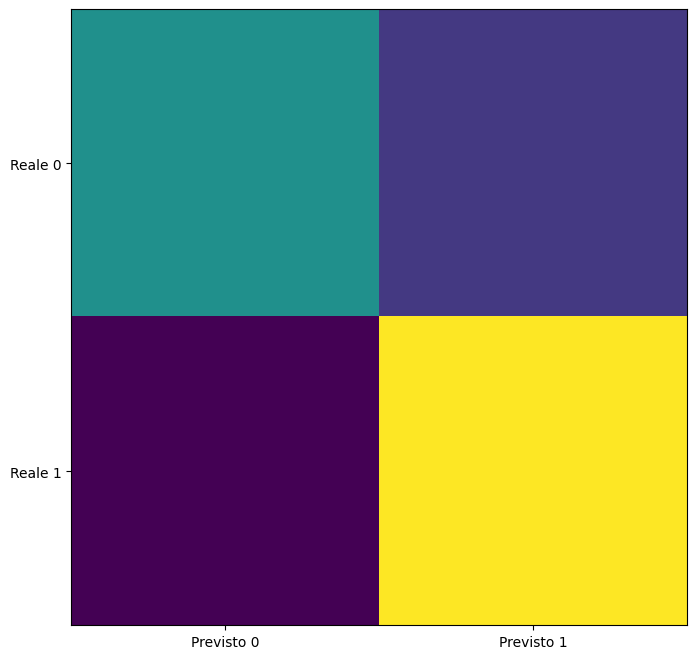

In [9]:
# Visualizzazione della matrice di confusione
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(cm) # Uso di imshow per visualizzare la matrice
ax.grid(False)
ax.xaxis.set(ticks=(0, 1), ticklabels=('Previsto 0', 'Previsto 1'))
ax.yaxis.set(ticks=(0, 1), ticklabels=('Reale 0', 'Reale 1'))
ax.set_ylim(1.5, -0.5) # Aggiustamento per la visualizzazione

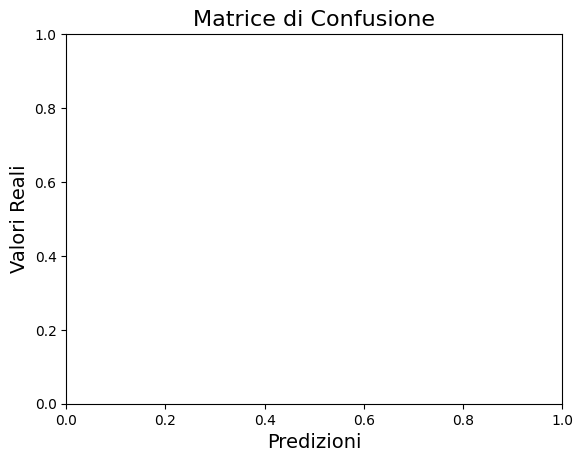

In [10]:
# Aggiungi i numeri alle celle
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='white', fontsize=20)

plt.xlabel('Predizioni', fontsize=14)
plt.ylabel('Valori Reali', fontsize=14)
plt.title('Matrice di Confusione', fontsize=16)
plt.show()